# k-Nearest Neighbors on Brainvita (Classification + Regression)

This notebook demonstrates the custom `KNNClassifier` and `KNNRegressor` on Brainvita board-state features.

KNN is a similarity-based baseline. Instead of learning coefficients or tree splits, it asks: do board states with similar engineered features have similar mobility? We use it for both high-mobility classification (`num_legal_moves >= 3`) and direct legal-move regression (`num_legal_moves`). Because distances drive the method, this notebook pays special attention to train-only standardization and sensitivity to `k`.

## Learning Objectives

1. Explain KNN as an instance-based method rather than a fitted parametric model.
2. Show why distance-based methods require train-only feature scaling.
3. Compare KNN classification against a majority-class baseline.
4. Sweep `k` to expose the bias-variance tradeoff.
5. Use `KNNRegressor` to predict the continuous legal-move count and compare against a mean predictor.


## Dataset and Targets

The notebook uses the shared curated Brainvita features so it can be compared fairly with the linear, tree, and neural-network notebooks.

We use two targets:

- Classification: `num_legal_moves >= 3`, a high-mobility label.
- Regression: `num_legal_moves`, the raw count of legal moves.

Feature scaling is essential because KNN compares distances. Without standardization, a feature with a large numeric range could dominate the distance calculation even if it is not more important.

## 1. Intuition

KNN is an instance-based model:

1. Store training data
2. For a query point, find the $k$ nearest training points
3. Aggregate neighbor labels/values

Distance metric and feature scaling are central to performance.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start='.'):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / 'src' / 'rice_ml').exists() and (q / 'data' / 'brainvita_dataset.csv').exists():
            return q
    raise FileNotFoundError('Could not locate repository root')


ROOT = find_repo_root('.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_PATH = ROOT / 'data' / 'brainvita_dataset.csv'
print('Repo root:', ROOT)
print('Dataset path:', DATA_PATH)

from rice_ml.supervised_learning import KNNClassifier, KNNRegressor

Repo root: /Users/LakshSarda/Desktop/CMOR_438_Repository
Dataset path: /Users/LakshSarda/Desktop/CMOR_438_Repository/data/brainvita_dataset.csv


The setup output confirms that the notebook resolves the repository root and dataset path correctly. The Matplotlib font-cache message is environmental; the useful checks are the printed root and CSV path.

Since KNN is implemented in the custom package, reaching this point without import or path errors confirms that the notebook can access both the package code and the Brainvita dataset before constructing any neighbor models.

In [2]:
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')

exclude_cols = {
    'num_legal_moves',
    'board_state',
    'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2',
    'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2',
}

raw_feature_cols = [c for c in header if c not in exclude_cols]
selected_cols = raw_feature_cols + ['num_legal_moves']
selected_idx = [header.index(c) for c in selected_cols]
arr = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1, usecols=selected_idx, dtype=float)

X_raw = arr[:, :-1]
y_reg = arr[:, -1]
y_bin = (y_reg >= 3.0).astype(int)

preferred_features = ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']
feature_cols = [c for c in preferred_features if c in raw_feature_cols]
keep_idx = [raw_feature_cols.index(c) for c in feature_cols]
X = X_raw[:, keep_idx]

# Reproducible subset for notebook runtime while preserving methodology.
rng_sample = np.random.default_rng(42)
sample_n = min(10000, X.shape[0])
sel = rng_sample.choice(X.shape[0], size=sample_n, replace=False)
X = X[sel]
y_reg = y_reg[sel]
y_bin = y_bin[sel]
print('Using sampled rows for notebook execution:', X.shape[0])

print(f'Rows: {X.shape[0]:,} | Features: {X.shape[1]}')
print('Positive class rate (num_legal_moves >= 3):', float(y_bin.mean()))
print('Features used:', feature_cols)


Using sampled rows for notebook execution: 10000
Rows: 10,000 | Features: 15
Positive class rate (num_legal_moves >= 3): 0.2875
Features used: ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']


The loading output confirms that this notebook uses a 10,000-row sample with 15 engineered features. The positive-class rate is `0.2875`, so high-mobility states are the minority class in this sample.

For KNN, the feature list is especially important because distance calculations depend directly on the chosen feature representation. The model is not learning coefficients; it is using similarity among these selected board summaries.

## 2. Classification Task (High-Mobility State)

For classification, KNN predicts the label by letting nearby training examples vote. We standardize features using only the training set, then compare KNN against a majority-class baseline. This makes the evaluation answer two questions: does local similarity beat a trivial class-frequency rule, and how sensitive is performance to the number of neighbors?

In [3]:
y_target = y_bin
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y_target[train_idx], y_target[test_idx]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma_safe = np.where(sigma < 1e-12, 1.0, sigma)

X_train = (X_train_raw - mu) / sigma_safe
X_test = (X_test_raw - mu) / sigma_safe

print('Train samples:', X_train.shape[0], '| Test samples:', X_test.shape[0])


Train samples: 8000 | Test samples: 2000


The classification split output confirms 8,000 training samples and 2,000 test samples. Because KNN predicts from stored training examples, this count is especially relevant: the classifier is comparing each test state against a large training reference set.

The split also confirms that the classification metrics below are measured on held-out rows rather than on the same examples used as neighbors during fitting.

In [4]:
def classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': np.array([[tn, fp], [fn, tp]])}

clf = KNNClassifier(n_neighbors=11, metric='euclidean', weights='distance')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

majority_class = int(np.bincount(y_train).argmax())
majority_pred = np.full_like(y_test, majority_class)
rows = [
    ('Majority baseline', classification_metrics(y_test, majority_pred)),
    ('KNN test', classification_metrics(y_test, y_pred)),
]

print('KNN classification comparison')
print('-' * 90)
print(f"{'Model':<22}{'Acc':>10}{'Precision':>12}{'Recall':>12}{'F1':>12}")
print('-' * 90)
for name, metrics in rows:
    print(f"{name:<22}{metrics['acc']:>10.4f}{metrics['precision']:>12.4f}{metrics['recall']:>12.4f}{metrics['f1']:>12.4f}")
print('-' * 90)
print('KNN confusion matrix [ [TN, FP], [FN, TP] ]')
print(rows[-1][1]['cm'])


KNN classification comparison
------------------------------------------------------------------------------------------
Model                        Acc   Precision      Recall          F1
------------------------------------------------------------------------------------------
Majority baseline         0.6925      0.0000      0.0000      0.0000
KNN test                  0.9805      0.9832      0.9528      0.9678
------------------------------------------------------------------------------------------
KNN confusion matrix [ [TN, FP], [FN, TP] ]
[[1375   10]
 [  29  586]]


The classification comparison shows that KNN is doing much more than following class imbalance. The majority baseline has accuracy `0.6925` but F1 `0.0000`, because it never predicts the high-mobility class.

The KNN classifier reaches accuracy `0.9805`, precision `0.9832`, recall `0.9528`, and F1 `0.9678`. The confusion matrix gives the count-level story: 1,375 true negatives, 10 false positives, 29 false negatives, and 586 true positives. The model is conservative enough to keep false positives low, but it still misses 29 positive states.

k sensitivity (test)
--------------------------------------------
     k      Accuracy            F1
--------------------------------------------
     1        0.9645        0.9414
     3        0.9745        0.9581
     5        0.9750        0.9589
     7        0.9745        0.9581
    11        0.9805        0.9678
    15        0.9780        0.9635
    21        0.9785        0.9641
--------------------------------------------


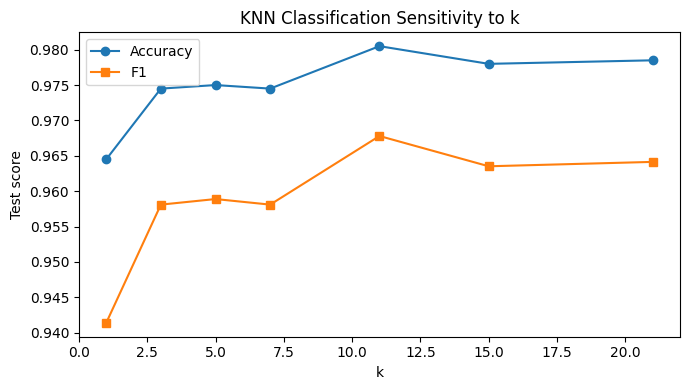

In [5]:
k_grid = [1, 3, 5, 7, 11, 15, 21]
accs = []
f1s = []
for k in k_grid:
    m = KNNClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    m.fit(X_train, y_train)
    met = classification_metrics(y_test, m.predict(X_test))
    accs.append(met['acc'])
    f1s.append(met['f1'])

print('k sensitivity (test)')
print('-' * 44)
print(f"{'k':>6}{'Accuracy':>14}{'F1':>14}")
print('-' * 44)
for k, acc, f1 in zip(k_grid, accs, f1s):
    print(f"{k:>6}{acc:>14.4f}{f1:>14.4f}")
print('-' * 44)

plt.figure(figsize=(7, 4))
plt.plot(k_grid, accs, marker='o', label='Accuracy')
plt.plot(k_grid, f1s, marker='s', label='F1')
plt.xlabel('k')
plt.ylabel('Test score')
plt.title('KNN Classification Sensitivity to k')
plt.legend()
plt.tight_layout()
plt.show()


The `k` sweep shows that the choice of neighbor count matters. At `k = 1`, accuracy is `0.9645` and F1 is `0.9414`, the weakest displayed result. Performance improves quickly by `k = 3` and `k = 5`, then reaches the best displayed result at `k = 11`, with accuracy `0.9805` and F1 `0.9678`.

The plot matches the table. Both accuracy and F1 rise from `k = 1` to `k = 11`, then dip or flatten for `k = 15` and `k = 21`. In this run, adding some smoothing helps, but too much smoothing does not improve the displayed F1 beyond the `k = 11` peak.

## 3. Regression Task (`num_legal_moves`)

For regression, KNN predicts the average legal-move count among nearby states. We compare it against a mean predictor, which always returns the training-set average. The mean baseline is important because KNN's runtime cost is higher than a constant model; it should earn that complexity by reducing RMSE and MAE.

In [6]:
y_target = y_reg
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y_target[train_idx], y_target[test_idx]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma_safe = np.where(sigma < 1e-12, 1.0, sigma)

X_train = (X_train_raw - mu) / sigma_safe
X_test = (X_test_raw - mu) / sigma_safe

print('Train samples:', X_train.shape[0], '| Test samples:', X_test.shape[0])


Train samples: 8000 | Test samples: 2000


The regression split again uses 8,000 training samples and 2,000 test samples, but the target is now the raw `num_legal_moves` count instead of the high-mobility label. This means the next metrics should be read in legal-move units, not as classification rates.

Using the same split size for classification and regression makes the two KNN tasks comparable in scale, even though the evaluation metrics are different.

Regression comparison
--------------------------------------------------------------------------------
Model                       R2           MSE          RMSE           MAE
--------------------------------------------------------------------------------
Mean baseline          -0.0022        1.2309        1.1094        0.8413
KNN regressor           0.9457        0.0666        0.2581        0.1577
--------------------------------------------------------------------------------


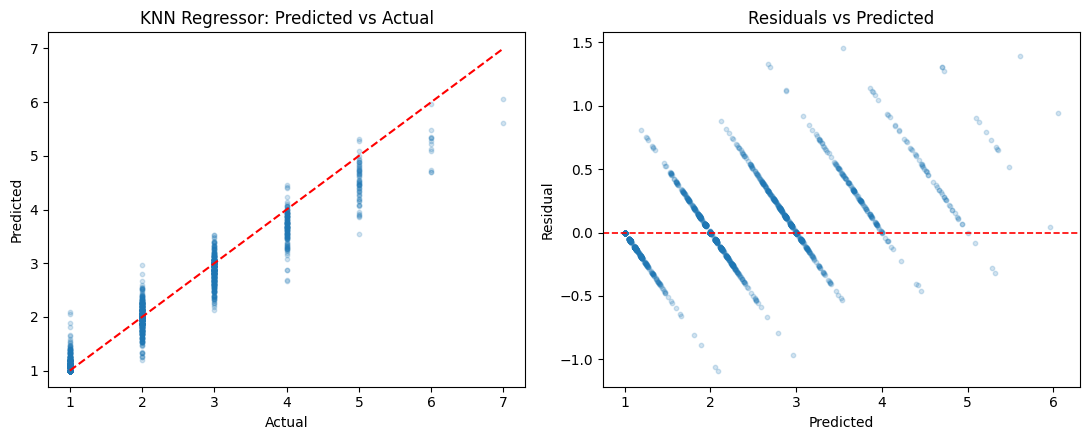

In [7]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    return {'r2': r2, 'mse': mse, 'rmse': rmse, 'mae': mae}

reg = KNNRegressor(n_neighbors=15, metric='euclidean', weights='distance')
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
mean_pred = np.full_like(y_test, y_train.mean(), dtype=float)

rows = [
    ('Mean baseline', regression_metrics(y_test, mean_pred)),
    ('KNN regressor', regression_metrics(y_test, y_pred)),
]

print('Regression comparison')
print('-' * 80)
print(f"{'Model':<18}{'R2':>12}{'MSE':>14}{'RMSE':>14}{'MAE':>14}")
print('-' * 80)
for name, metrics in rows:
    print(f"{name:<18}{metrics['r2']:>12.4f}{metrics['mse']:>14.4f}{metrics['rmse']:>14.4f}{metrics['mae']:>14.4f}")
print('-' * 80)

resid = y_test - y_pred
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].scatter(y_test, y_pred, alpha=0.2, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax[0].plot(lims, lims, 'r--')
ax[0].set_xlabel('Actual')
ax[0].set_ylabel('Predicted')
ax[0].set_title('KNN Regressor: Predicted vs Actual')

ax[1].scatter(y_pred, resid, alpha=0.2, s=10)
ax[1].axhline(0, color='r', linestyle='--', linewidth=1.2)
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Residual')
ax[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()


The regression table shows a large improvement over the mean predictor. The baseline has `R2 = -0.0022`, RMSE `1.1094`, and MAE `0.8413`. The KNN regressor improves to `R2 = 0.9457`, RMSE `0.2581`, and MAE `0.1577`, so nearby states in the standardized feature space usually have similar legal-move counts.

The predicted-vs-actual plot follows the red diagonal overall, but the points form vertical bands because the actual target is an integer count. The residual plot shows diagonal stripes rather than a random cloud, which means the regressor is accurate but still has visible structure in its errors. Some higher-count states also show more spread, so the model is not equally tight across every part of the target range.

The correct conclusion from this output is not that KNN perfectly models the move count. It is that local averaging is a strong baseline for this sampled dataset, while still leaving structured residual patterns that future models can try to reduce.

## 4. Conclusion

KNN is a strong nonparametric comparison point on the sampled Brainvita data. For classification, the `k = 11` run reaches accuracy `0.9805`, precision `0.9832`, recall `0.9528`, and F1 `0.9678`. For regression, the KNN regressor reaches `R2 = 0.9457`, RMSE `0.2581`, and MAE `0.1577`.

The classification output shows that local similarity is doing real work beyond class imbalance. The majority baseline has F1 `0.0000`, while KNN correctly identifies 586 positive test states and misses 29. The `k` sweep shows the best displayed F1 at `k = 11`; smaller `k` values are noisier, and larger displayed values flatten slightly below the peak.

The regression output is also much better than the mean baseline, but the residual plot still shows structure. The diagonal residual bands mean that neighbor averaging predicts legal-move count well overall but does not eliminate systematic-looking errors from the integer target and local averaging.

The main limitation is computational and interpretive: KNN performs well on the 10,000-row sample, but it stores examples rather than learning a compact set of coefficients or tree rules, and its behavior depends heavily on the chosen distance scale and `k`.
